# Reproducing McKevitt et al. (2026)

[McKevitt et al. (2026)](https://academic.oup.com/pasj/article/78/4/1524/8731000) uses a snapshot of the [Cheung et al. (2018)](https://www.nature.com/articles/s41550-018-0629-3) MURaM flare simulation to simulate an observation from EUVST-SW. This notebook explains how to reproduce the intensity and velocity figures from the base simulation data.

## Before you start

| Resource | Needed |
| --- | --- |
| Download | 1.2 GB of simulation data |
| Disk | about 20 GB, mostly for the synthesis file |
| Memory | peaks near 110 GB |
| Wall clock | about 8 minutes on 64 cores, which is longer with more Monte Carlo iterations |

Contribution functions come from CHIANTI through [fiasco](https://fiasco.readthedocs.io/), which builds a local HDF5 copy of the database the first time it is used.

In [1]:
import astropy.units as u
import dill
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import LogNorm
from pathlib import Path

from euvst_response import (
    load_instrument_response_results,
    get_results_for_combination,
    create_sunpy_maps_from_combo,
    summary_table,
)

## 1. Get the simulation snapshot

The MURaM simulation is available at [purl.stanford.edu/dv883vb9686](https://purl.stanford.edu/dv883vb9686).

An optically thin calculation needs the temperature, density, and velocity along the line of sight. In this case, that is the vertical velocity.

| File | Quantity | Unit |
| --- | --- | --- |
| `eosT.0270000` | temperature | K |
| `result_prim_0.0270000` | density | g/cm^3 |
| `result_prim_2.0270000` | vertical velocity | cm/s |

`0270000` is the snapshot used in the paper.

In [2]:
import subprocess

BASE = "https://stacks.stanford.edu/file/druid:dv883vb9686"
SNAPSHOT = "0270000"

files = {
    "temp": f"eosT.{SNAPSHOT}",
    "rho": f"result_prim_0.{SNAPSHOT}",
    "vz": f"result_prim_2.{SNAPSHOT}",
}

for folder, name in files.items():
    path = Path("data/atmosphere") / folder / name
    path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["curl", "-sS", "-L", "-o", str(path), f"{BASE}/{name}"], check=True)
    print(f"{name}: {path.stat().st_size} bytes")

eosT.0270000: 402653184 bytes
result_prim_0.0270000: 402653184 bytes
result_prim_2.0270000: 402653184 bytes

> **Which file holds the vertical velocity.** `result_prim_1`, `_2` and `_3` are the three velocity components, but which of them is vertical depends on the run. In this one, the vertical velocity is `result_prim_2`.

### The grid

`--cube-shape` is the order the cells are written in, so `512 768 256` for these files. The `--voxel-d*` options describe the axes after the reader has put them in heliocentric order: `dx` for the 512-cell axis, `dy` for the 256-cell axis, and `dz` for the 768-cell vertical one.

## 2. Synthesise the spectra

This step reads the three cubes, builds the VDEM, introduces the contribution functions, and writes a synthesis file.

In [3]:
!synthesise-spectra \
  --data-dir ./data/atmosphere \
  --lines Fe13_194.9800 Fe14_194.9910 Fe13_194.9970 Fe12_195.0040 Fe11_195.0250 \
          Fe09_195.0290 Mn10_195.0360 Fe11_195.0540 Fe12_195.0860 Fe12_195.1190 \
          Fe11_195.1470 Fe10_195.1510 Fe13_195.1600 Ni11_195.1600 Fe12_195.1790 \
          Fe09_195.2300 Fe14_195.2450 Fe11_195.2450 Fe10_195.2600 Fe10_195.2610 \
          Fe12_195.2660 \
  --abundance sun_coronal_1992_feldman_ext \
  --output-dir ./run/input \
  --output-name mckevitt2026.pkl \
  --temp-file temp/eosT.0270000 \
  --rho-file rho/result_prim_0.0270000 \
  --vz-file vz/result_prim_2.0270000 \
  --cube-shape 512 768 256 \
  --voxel-dx "0.192 Mm" \
  --voxel-dy "0.192 Mm" \
  --voxel-dz "0.064 Mm" \
  --vel-res "5.0 km/s" \
  --vel-lim "300.0 km/s" \
  --integration-axis z

STATIC MODE - Single timestep synthesis
  Data directory: data/atmosphere
  Cube shape: [512, 768, 256]
  Voxel sizes: 0.192 Mm x 0.192 Mm x 0.064 Mm
  Integration axis: z
  Velocity grid: +/-300.0 km / s at 5.0 km / s resolution
  Precision: <class 'numpy.float64'>
  Lines: ['Fe13_194.9800', 'Fe14_194.9910', 'Fe13_194.9970', 'Fe12_195.0040', 'Fe11_195.0250', 'Fe09_195.0290', 'Mn10_195.0360', 'Fe11_195.0540', 'Fe12_195.0860', 'Fe12_195.1190', 'Fe11_195.1470', 'Fe10_195.1510', 'Fe13_195.1600', 'Ni11_195.1600', 'Fe12_195.1790', 'Fe09_195.2300', 'Fe14_195.2450', 'Fe11_195.2450', 'Fe10_195.2600', 'Fe10_195.2610', 'Fe12_195.2660']
  Abundance: sun_coronal_1992_feldman_ext

Loading cubes (14.28/540.81 GB)
Computing contribution functions via fiasco (22.35/540.81 GB)
  Parallel: 8 workers for 8 ions
  Fe13_194.9800: requested 194.9800 Angstrom, matched 194.9800 Angstrom (delta=0.0000 Angstrom)
  Fe13_194.9970: requested 194.9970 Angstrom, matched 194.9970 Angstrom (delta=0.0000 Angstrom)
  Fe

The line list is Fe XII 195.119 emission line and bright background lines in the same spectral window.

`--integration-axis z` is the top-down view, and is why only the vertical velocity was needed. A side view (`x` or `y`) integrates through the box horizontally and needs the matching `--vx-file` or `--vy-file` instead.

Synthesis prints the requested and matched wavelength for every line. A large difference means CHIANTI has no such transition for that ion and a neighbouring one was picked up instead. See [naming spectral lines](../synthesis/#naming-spectral-lines).

## 3. The heliocentric intensity map

This is the simulation atmosphere before the instrument. It shows the emission integrated along the line of sight and across the line profile at the simulation resolution.

In [4]:
with open("run/input/mckevitt2026.pkl", "rb") as f:
    synthesis = dill.load(f)

line_cube = synthesis["line_cubes"]["Fe12_195.1190"]
print(f"cube shape {line_cube.data.shape}, unit {line_cube.unit}")

cube shape (256, 512, 121), unit erg / (s sr cm3)

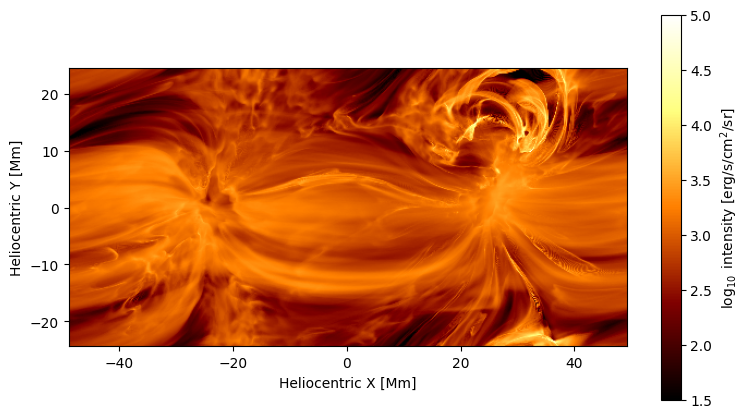

In [5]:
# Integrate the line profile. The cube is indexed (y, x, wavelength) and holds a
# spectral radiance, so the sum over the last axis needs the wavelength spacing.
cube = line_cube.to(u.erg / u.s / u.cm**2 / u.sr / u.cm)
wavelengths = cube.axis_world_coords(-1)[0].to(u.cm)
d_lambda = np.gradient(wavelengths)
intensity = (cube.data * d_lambda.value).sum(axis=-1) * u.erg / u.s / u.cm**2 / u.sr

y = line_cube.axis_world_coords(0)[0].to(u.Mm)
x = line_cube.axis_world_coords(1)[0].to(u.Mm)

fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(
    np.log10(intensity.value),
    origin="lower",
    extent=[x[0].value, x[-1].value, y[0].value, y[-1].value],
    cmap="afmhot",
    vmin=1.5,
    vmax=5.0,
    aspect="equal",
)
ax.set_xlabel("Heliocentric X [Mm]")
ax.set_ylabel("Heliocentric Y [Mm]")
fig.colorbar(image, ax=ax, label=r"$\log_{10}$ intensity [erg/s/cm$^2$/sr]")
plt.show()

## 4. Simulate the instrument

`slit_width: 0.4 arcsec` sets both the slit and the raster step, and `offchip_bin_slit: 2` sums pairs of pixels along the slit after read-out. Both can be given as lists to sweep them (see [the configuration file reference](../instrument-response/#configuration-file)), but here they are single values.

Here we use just one Monte Carlo iteration, as we just show one observation, but many can be used to study measurement precision of the instrument, as in the paper.

In [6]:
%%writefile run/input/mckevitt2026.yaml
instrument: SWC
synthesis_file: ./run/input/mckevitt2026.pkl
reference_line: Fe12_195.1190

n_iter: 1
ncpu: -1
offchip_bin_slit: 2
fit_signals: dn

simulation:
  slit_width: 0.4 arcsec
  expos: 40 s
  psf: True

detector:
  ccd_temperature: -60 Celsius

filter:
  c_thickness: 40 angstrom

fitting:
  primary_component: 0
  backend: scipy
  constrain_positive_intensity: true
  components:
    - wavelength: 195.119 angstrom   # Fe XII 195.119
      amplitude_greater_than: 1      # brighter than the blend
    - wavelength: 195.179 angstrom   # Fe XII 195.179
      tie_center: 0                  # same velocity as component 0
      tie_width: 0                   # same width as component 0

Writing run/input/mckevitt2026.yaml

In [7]:
!eclipse --config ./run/input/mckevitt2026.yaml


  ______ _____ _      _____ _____   _____ ______ 
 |  ____/ ____| |    |_   _|  __ \ / ____|  ____|
 | |__ | |    | |      | | | |__) | (___ | |__   
 |  __|| |    | |      | | |  ___/ \___ \|  __|  
 | |___| |____| |____ _| |_| |     ____) | |____ 
 |______\_____|______|_____|_|    |_____/|______|

ECLIPSE: Emission Calculation and Line Prediction for SOLAR-C EUVST

Contact: James McKevitt (jm2@mssl.ucl.ac.uk). License: Contact for permission to use.

Running instrument response simulation with config: ./run/input/mckevitt2026.yaml
------------------------------------------------------------
Multi-component fitting enabled: 2 components (primary=0, 7 params, backend=scipy (forced))
Fitting only 'dn' signal (skipping 'photon')
Off-chip slit binning values: [2] (ground-based, all noise per pixel before summation)
/gpfs/data/fs70652/jamesm/solar/wt-tutorial/euvst_response/main.py:279: UserWarning: The SWC PSF is the modelled PSF including simulations and some microroughness measurements

## 5. The helioprojective intensity and velocity maps

`summary_table` lists every combination in the results file along with the exact parameter names. Use this before writing the `get_results_for_combination` call.

In [8]:
results = load_instrument_response_results("run/result/mckevitt2026.pkl")
summary_table(results)

Software version : 0.8.0
Git commit       : 49a543fc137803218275410bec62b1d6736d5870

detector.ccd_temperature | detector.dark_current    | detector.filter_distance | detector.gain_e_per_dn   | detector.material        | detector.max_dn          | detector.pix_size        | detector.plate_scale_angle | detector.qe_euv          | detector.qe_vis          | detector.read_noise_rms  | detector.wvl_res         | filter.al_thickness      | filter.c_thickness       | filter.mesh_throughput   | filter.oxide_thickness   | filter.table_thickness   | offchip_bin_slit         | simulation.enable_pinholes | simulation.expos         | simulation.instrument    | simulation.n_iter        | simulation.ncpu          | simulation.pinhole_positions_spectral | simulation.psf           | simulation.slit_width    | simulation.vis_sl        | telescope.D_ap           | telescope.microroughness_sigma | telescope.psf_params     | telescope.psf_type      
--------------------------------------------------------

In [9]:
combination = get_results_for_combination(results, **{
    "simulation.slit_width": 0.4 * u.arcsec,
    "simulation.expos": 40 * u.s,
    "offchip_bin_slit": 2,
})

maps = create_sunpy_maps_from_combo(
    combination,
    rest_wavelength=195.119 * u.AA,
    data_type="dn",
)

print(sorted(maps))

['line_width_from_fit', 'line_width_mean', 'line_width_std', 'total_dn', 'total_photons', 'velocity_err', 'velocity_from_fit', 'velocity_mean', 'velocity_std', 'velocity_true']

For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]

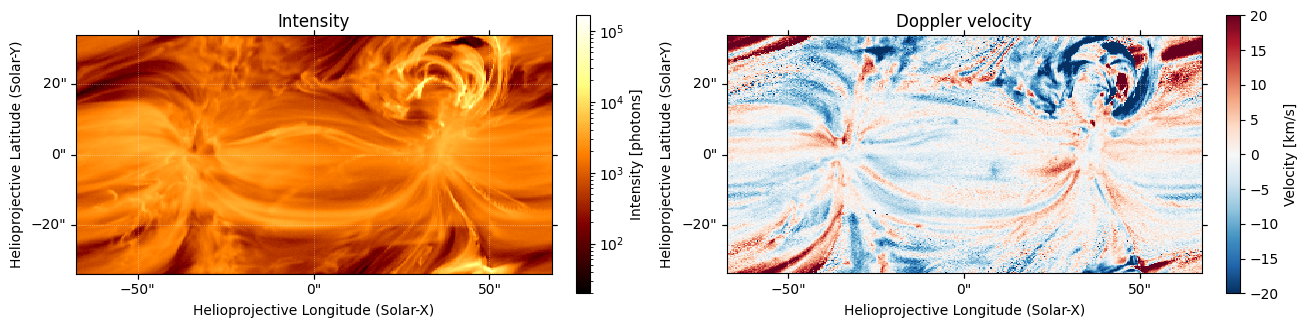

In [10]:
fig = plt.figure(figsize=(13, 4), layout="constrained")

ax = fig.add_subplot(1, 2, 1, projection=maps["total_photons"])
image = maps["total_photons"].plot(
    axes=ax, norm=LogNorm(vmin=2e1, vmax=1.65e5), cmap="afmhot"
)
ax.set_title("Intensity")
fig.colorbar(image, ax=ax, label="Intensity [photons]", shrink=0.8)

ax = fig.add_subplot(1, 2, 2, projection=maps["velocity_from_fit"])
image = maps["velocity_from_fit"].plot(axes=ax, vmin=-20, vmax=20, cmap="RdBu_r")
ax.set_title("Doppler velocity")
fig.colorbar(image, ax=ax, label="Velocity [km/s]", shrink=0.8)

plt.show()

`create_sunpy_maps_from_combo` returns more than these two maps. `total_photons` is the signal before the detector and `total_dn` the same after it; `velocity_from_fit` is the first fit of the first iteration, `velocity_mean` and `velocity_std` the mean and spread across iterations, and `velocity_err` the difference from the known truth. They are ordinary SunPy maps, so all the SunPy map functions can be used.